# Spam SMS Classification — Machine Learning Assignment
**Student:** Nurlan JABIYEV | **ID:** 0568  
**Dataset:** [SPAM Text Message Classification (Kaggle)](
https://www.kaggle.com/datasets/team-ai/spam-text-message-classification)  
**Task:** Binary classification — detect spam SMS messages  
**Algorithm:** Decision Tree (implemented from scratch)

### AI Assistance & Prompts Used
- "Explain how Decision Tree splitting works with Gini impurity formula"
- "How to implement TF-IDF from scratch using only numpy"
- "What is the difference between Bag of Words and TF-IDF for text classification"
- "How does 5-fold cross validation work mathematically"
- "Explain F1 score for imbalanced binary classification"

## Part 1 — Problem Description

### SMS Spam Detection

Spam SMS messages are unsolicited text messages sent in bulk, typically for fraudulent purposes such as phishing, prize scams, or fake offers. Automatically detecting spam protects users from financial harm and reduces the burden of manual filtering on mobile carriers.

### Dataset
The dataset contains **5575 labelled SMS messages** collected from various public sources. Each row has:
- `Category`: either `ham` (legitimate) or `spam`
- `Message`: the raw SMS text

### Class Imbalance
The dataset is heavily imbalanced: approximately **87% ham** and **13% spam**. This means a naive classifier that always predicts "ham" would achieve ~87% accuracy while completely failing to detect any spam.

### Why F1 Score Instead of Accuracy?
Because of the class imbalance, **accuracy is misleading**. The F1 score is the harmonic mean of Precision and Recall:

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

It penalises models that ignore the minority (spam) class, making it the appropriate metric for this task. We compute F1 for the spam class (positive class = 1).

In [22]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import math
import itertools
import time
from sklearn.metrics import f1_score

STOPWORDS = {'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
'yourself','yourselves','he','him','his','himself','she','her','hers','herself','it',
'its','itself','they','them','their','theirs','themselves','what','which','who','whom',
'this','that','these','those','am','is','are','was','were','be','been','being','have',
'has','had','having','do','does','did','doing','a','an','the','and','but','if','or',
'because','as','until','while','of','at','by','for','with','about','against','between',
'into','through','during','before','after','above','below','to','from','up','down','in',
'out','on','off','over','under','again','further','then','once','here','there','when',
'where','why','how','all','both','each','few','more','most','other','some','such','no',
'nor','not','only','own','same','so','than','too','very','s','t','can','will','just',
'don','should','now','d','ll','m','o','re','ve','y','ain','aren','couldn','didn',
'doesn','hadn','hasn','haven','isn','ma','mightn','mustn','needn','shan','shouldn',
'wasn','weren','won','wouldn'}

print("Imports complete. STOPWORDS loaded:", len(STOPWORDS), "words")

Imports complete. STOPWORDS loaded: 152 words


## Part 2 — Load Dataset & Train/Test Split

In [23]:
import os
filepath = r"C:\Users\HP\Desktop\Machine Learning\SPAM text message 20170820 - Data.csv"
if not os.path.exists(filepath):
    filepath = "SPAM text message 20170820 - Data.csv"
df = pd.read_csv(filepath, encoding='latin-1')

# Keep only the two relevant columns
df = df[['Category', 'Message']].copy()

# Encode labels: spam=1, ham=0
df['Label'] = df['Category'].map({'spam': 1, 'ham': 0})

# Fixed train/test split: first 4460 rows train, last 1115 rows test
train_df = df.iloc[:4460].reset_index(drop=True)
test_df  = df.iloc[4460:].reset_index(drop=True)

X_train = train_df['Message']
y_train = train_df['Label'].values.astype(int)

X_test = test_df['Message']
y_test = test_df['Label'].values.astype(int)

print(f"Full dataset shape : {df.shape}")
print(f"Training set shape : X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape     : X={X_test.shape}, y={y_test.shape}")
print()
df.head()

Full dataset shape : (5572, 3)
Training set shape : X=(4460,), y=(4460,)
Test set shape     : X=(1112,), y=(1112,)



,Category,Message,Label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Part 2b — Class Distribution

Training set class distribution:
  ham  (0):  3858  (86.5%)
  spam (1):   602  (13.5%)


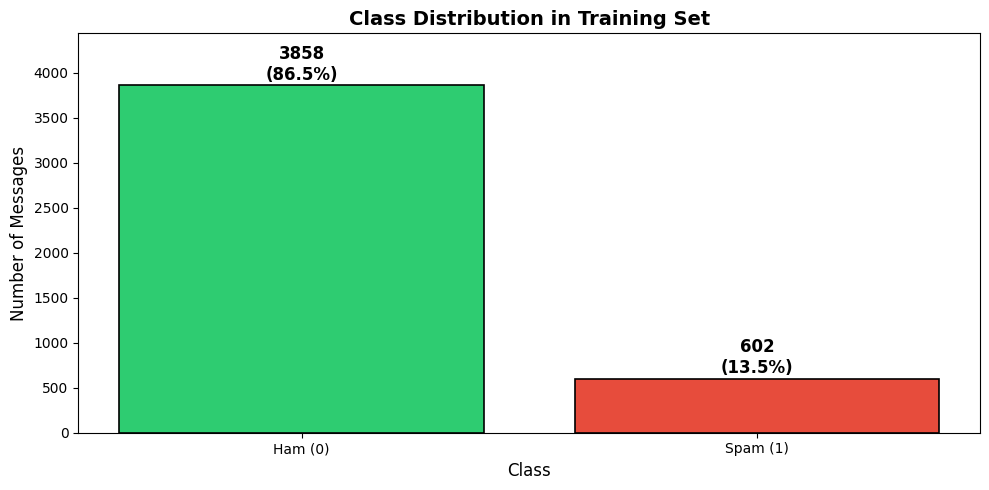

In [24]:
ham_count  = int(np.sum(y_train == 0))
spam_count = int(np.sum(y_train == 1))
total      = len(y_train)

print(f"Training set class distribution:")
print(f"  ham  (0): {ham_count:>5}  ({100*ham_count/total:.1f}%)")
print(f"  spam (1): {spam_count:>5}  ({100*spam_count/total:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(['Ham (0)', 'Spam (1)'], [ham_count, spam_count],
              color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)

for bar, count, pct in zip(bars, [ham_count, spam_count],
                            [100*ham_count/total, 100*spam_count/total]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Messages', fontsize=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylim(0, ham_count * 1.15)
plt.tight_layout()
plt.show()

## Part 3 — Text Preprocessing

Raw SMS text must be cleaned before it can be used as numeric features. The preprocessing pipeline performs the following steps:

1. **Lowercasing** — converts all characters to lowercase so `FREE` and `free` are treated as the same token.
2. **Punctuation removal** — strips characters like `!`, `?`, `,`, `.` which do not carry semantic meaning for classification.
3. **Tokenisation** — splits the cleaned text on whitespace to produce a list of words.
4. **Stopword removal** — removes highly common function words (e.g. `the`, `a`, `is`) that appear in almost every message and would dilute the signal from discriminative words like `free`, `winner`, `prize`.

In [25]:
def preprocess(text):
    """Lowercase, remove punctuation, tokenize, remove stopwords."""
    import string
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens

# Quick sanity check
sample = "FREE entry to WIN a £1000 prize! Call 09061234567 NOW!"
print("Raw     :", sample)
print("Cleaned :", preprocess(sample))

Raw     : FREE entry to WIN a £1000 prize! Call 09061234567 NOW!
Cleaned : ['free', 'entry', 'win', '£1000', 'prize', 'call', '09061234567']


## Part 3b — Bag of Words (BoW)

**Bag of Words** represents each document as a fixed-length vector of word counts. The vocabulary is built from the training corpus by selecting the top `max_features` most frequent words.

For a vocabulary of size $V$ and a corpus of $N$ documents, the BoW matrix has shape $(N, V)$ where entry $(i, j)$ is the count of word $j$ in document $i$.

**Limitation:** BoW treats all words equally regardless of how informative they are. A word like `free` that appears in many spam messages gets the same raw weight as a very common word. TF-IDF addresses this.

In [26]:
class BagOfWords:
    """Bag of Words vectorizer using only numpy and collections."""
    def __init__(self, max_features=3000):
        self.max_features = max_features
        self.vocab = {}
        self.vocab_size = 0

    def fit(self, corpus):
        """Build vocabulary from corpus (list of raw texts), top max_features by frequency."""
        word_counts = Counter()
        for text in corpus:
            tokens = preprocess(text)
            word_counts.update(tokens)
        top_words = [w for w, _ in word_counts.most_common(self.max_features)]
        self.vocab = {word: idx for idx, word in enumerate(top_words)}
        self.vocab_size = len(self.vocab)
        return self

    def transform(self, corpus):
        """Transform corpus to BoW matrix of shape (n_docs, vocab_size)."""
        X = np.zeros((len(corpus), self.vocab_size), dtype=np.float32)
        for i, text in enumerate(corpus):
            tokens = preprocess(text)
            for token in tokens:
                if token in self.vocab:
                    X[i, self.vocab[token]] += 1
        X = (X > 0).astype(float)
        return X

    def fit_transform(self, corpus):
        return self.fit(corpus).transform(corpus)

print("BagOfWords class defined.")

BagOfWords class defined.


## Part 3c — TF-IDF

**TF-IDF (Term Frequency–Inverse Document Frequency)** weights each word by how often it appears in a document relative to how common it is across all documents.

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{DF}(t)}\right) + 1$$

where $N$ is the number of documents and $\text{DF}(t)$ is the number of documents containing term $t$. The $+1$ smoothing prevents division by zero.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Words that appear in many documents (like common words that survive stopword removal) receive a low IDF weight, while rare but discriminative words (like `prize`, `winner`) receive high weight.

In [27]:
class TFIDF:
    """TF-IDF vectorizer using only numpy and collections."""
    def __init__(self, max_features=3000):
        self.max_features = max_features
        self.vocab = {}
        self.idf_values = {}
        self.vocab_size = 0
        self.n_docs = 0

    def fit(self, corpus):
        """Build vocabulary and compute IDF values. Top max_features by document frequency."""
        self.n_docs = len(corpus)
        doc_freq = Counter()
        for text in corpus:
            tokens = set(preprocess(text))
            doc_freq.update(tokens)
        top_words = [w for w, _ in doc_freq.most_common(self.max_features)]
        self.vocab = {word: idx for idx, word in enumerate(top_words)}
        self.vocab_size = len(self.vocab)
        self.idf_values = {}
        for word in self.vocab:
            df = doc_freq[word]
            self.idf_values[word] = math.log((1 + self.n_docs) / (1 + df)) + 1
        return self

    def transform(self, corpus):
        """Transform corpus to TF-IDF matrix of shape (n_docs, vocab_size)."""
        X = np.zeros((len(corpus), self.vocab_size), dtype=np.float32)
        for i, text in enumerate(corpus):
            tokens = preprocess(text)
            if not tokens:
                continue
            tf_counts = Counter(tokens)
            total = len(tokens)
            for word, count in tf_counts.items():
                if word in self.vocab:
                    tf = count / total
                    idf = self.idf_values[word]
                    X[i, self.vocab[word]] = tf * idf
        X = (X > 0).astype(float)
        return X

    def fit_transform(self, corpus):
        return self.fit(corpus).transform(corpus)

print("TFIDF class defined.")

TFIDF class defined.


## Part 3d — Preprocessing Pipeline Demonstration

We now demonstrate the full preprocessing pipeline (BoW and TF-IDF) on example messages from the training and test sets.

In [28]:
# Build both vectorizers on training data
bow_demo  = BagOfWords(max_features=3000)
tfidf_demo = TFIDF(max_features=3000)

X_train_list = list(X_train)
X_train_bow_demo  = bow_demo.fit_transform(X_train_list)
X_train_tfidf_demo = tfidf_demo.fit_transform(X_train_list)

# Reverse vocab for lookup: idx -> word
bow_rev   = {v: k for k, v in bow_demo.vocab.items()}
tfidf_rev = {v: k for k, v in tfidf_demo.vocab.items()}

demo_indices = [0, 10, 100]
print("=" * 70)
print("TRAINING SET EXAMPLES")
print("=" * 70)
for idx in demo_indices:
    raw = X_train.iloc[idx]
    tokens = preprocess(raw)
    bow_vec = X_train_bow_demo[idx]
    tfidf_vec = X_train_tfidf_demo[idx]

    # Top 5 nonzero BoW features
    bow_nonzero = np.where(bow_vec > 0)[0]
    bow_top5_idx = bow_nonzero[np.argsort(bow_vec[bow_nonzero])[::-1][:5]]
    bow_top5 = [(bow_rev[i], int(bow_vec[i])) for i in bow_top5_idx]

    # Top 5 nonzero TF-IDF features
    tfidf_nonzero = np.where(tfidf_vec > 0)[0]
    tfidf_top5_idx = tfidf_nonzero[np.argsort(tfidf_vec[tfidf_nonzero])[::-1][:5]]
    tfidf_top5 = [(tfidf_rev[i], float(tfidf_vec[i])) for i in tfidf_top5_idx]

    label_str = 'SPAM' if y_train[idx] == 1 else 'HAM'
    print(f"\n[Index {idx}] Label: {label_str}")
    print(f"  Raw text  : {raw[:80]}")
    print(f"  Tokens    : {tokens[:10]}")
    print(f"  BoW top5  : {bow_top5}")
    print(f"  TFIDF top5: {[(w, round(s,4)) for w,s in tfidf_top5]}")

# Transform test set with already-fitted vectorizers
X_test_list = list(X_test)
X_test_bow_demo   = bow_demo.transform(X_test_list)
X_test_tfidf_demo = tfidf_demo.transform(X_test_list)

print("\n" + "=" * 70)
print("TEST SET EXAMPLES (vectorizers already fitted on train)")
print("=" * 70)
for idx in demo_indices:
    raw = X_test.iloc[idx]
    tokens = preprocess(raw)
    bow_vec = X_test_bow_demo[idx]
    tfidf_vec = X_test_tfidf_demo[idx]

    bow_nonzero = np.where(bow_vec > 0)[0]
    bow_top5_idx = bow_nonzero[np.argsort(bow_vec[bow_nonzero])[::-1][:5]] if len(bow_nonzero) > 0 else []
    bow_top5 = [(bow_rev[i], int(bow_vec[i])) for i in bow_top5_idx]

    tfidf_nonzero = np.where(tfidf_vec > 0)[0]
    tfidf_top5_idx = tfidf_nonzero[np.argsort(tfidf_vec[tfidf_nonzero])[::-1][:5]] if len(tfidf_nonzero) > 0 else []
    tfidf_top5 = [(tfidf_rev[i], float(tfidf_vec[i])) for i in tfidf_top5_idx]

    label_str = 'SPAM' if y_test[idx] == 1 else 'HAM'
    print(f"\n[Index {idx}] Label: {label_str}")
    print(f"  Raw text  : {raw[:80]}")
    print(f"  Tokens    : {tokens[:10]}")
    print(f"  BoW top5  : {bow_top5}")
    print(f"  TFIDF top5: {[(w, round(s,4)) for w,s in tfidf_top5]}")

TRAINING SET EXAMPLES

[Index 0] Label: HAM
  Raw text  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
  Tokens    : ['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la']
  BoW top5  : [('buffet', 1), ('la', 1), ('bugis', 1), ('cine', 1), ('crazy', 1)]
  TFIDF top5: [('buffet', 1.0), ('la', 1.0), ('bugis', 1.0), ('cine', 1.0), ('crazy', 1.0)]

[Index 10] Label: HAM
  Raw text  : I'm gonna be home soon and i don't want to talk about this stuff anymore tonight
  Tokens    : ['im', 'gonna', 'home', 'soon', 'dont', 'want', 'talk', 'stuff', 'anymore', 'tonight']
  BoW top5  : [('anymore', 1), ('enough', 1), ('stuff', 1), ('talk', 1), ('tonight', 1)]
  TFIDF top5: [('anymore', 1.0), ('enough', 1.0), ('stuff', 1.0), ('talk', 1.0), ('tonight', 1.0)]

[Index 100] Label: HAM
  Raw text  : Please don't text me anymore. I have nothing else to say.
  Tokens    : ['please', 'dont', 'text', 'anymore', 'nothing', 'else', 'say']
  BoW 

## Part 3e — Decision Tree Algorithm Explanation

A **Decision Tree** is a hierarchical model that recursively partitions the feature space by selecting the feature and threshold that best separates the classes at each node.

### How Splitting Works
At each node, the algorithm evaluates all candidate features. For each feature, it computes the **Information Gain** of splitting on that feature:

$$IG = \text{Impurity}(\text{parent}) - \left[\frac{|L|}{|P|} \cdot \text{Impurity}(L) + \frac{|R|}{|P|} \cdot \text{Impurity}(R)\right]$$

The feature with the highest $IG$ is chosen as the split.

### Gini Impurity
$$\text{Gini}(y) = 1 - \sum_{c} p_c^2$$

Gini = 0 means a pure node (all one class). Gini = 0.5 is maximum impurity for binary classification.

### Entropy
$$H(y) = -\sum_{c} p_c \log_2(p_c)$$

Entropy = 0 means a pure node. Maximum entropy for binary is 1 bit.

### Leaf Node Conditions
A node becomes a **leaf** (no further splitting) when:
- Maximum depth is reached (`max_depth`)
- Too few samples to split (`min_samples_split`)
- All samples have the same label (pure node)
- No split improves impurity ($IG \leq 0$)

At a leaf, the prediction is the **majority class** of the samples that reached that node.

### Why Decision Trees for Text?
For BoW/TF-IDF features, each feature is a word's presence/count. Decision trees can capture rules like "if `free` is present AND `call` is present → spam", which mirrors human intuition about spam language.

In [29]:
class Node:
    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.left = None
        self.right = None
        self.is_leaf = False
        self.prediction = None
        self.n_samples = None
        self.impurity = None


class DecisionTreeClassifier:
    """Decision Tree for binary classification, implemented from scratch with numpy."""

    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None

    def _gini(self, y):
        if len(y) == 0:
            return 0.0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _entropy(self, y):
        if len(y) == 0:
            return 0.0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-10))

    def _impurity(self, y):
        if self.criterion == 'gini':
            return self._gini(y)
        return self._entropy(y)

    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = 0.5
        parent_impurity = self._impurity(y)
        n_samples, n_features = X.shape

        # Only check features that have any nonzero value
        nonzero_features = np.where(np.any(X > 0, axis=0))[0]
        # Limit to 200 features max for speed
        if len(nonzero_features) > 200:
            # pick features with most variance
            variances = np.var(X[:, nonzero_features], axis=0)
            top_idx = np.argsort(variances)[::-1][:200]
            nonzero_features = nonzero_features[top_idx]

        for feat_idx in nonzero_features:
            threshold = 0.5  # binary: present or not
            left_mask = X[:, feat_idx] <= threshold
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            y_left = y[left_mask]
            y_right = y[right_mask]
            w_left = len(y_left) / n_samples
            w_right = len(y_right) / n_samples
            gain = parent_impurity - (w_left * self._impurity(y_left) +
                                      w_right * self._impurity(y_right))
            if gain > best_gain:
                best_gain = gain
                best_feature = feat_idx
                best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth):
        node = Node()
        node.n_samples = len(y)
        node.impurity = self._impurity(y)

        # Leaf conditions
        if (depth >= self.max_depth or
                len(y) < self.min_samples_split or
                len(np.unique(y)) == 1):
            node.is_leaf = True
            node.prediction = int(np.bincount(y.astype(int)).argmax())
            return node

        feature_idx, threshold, gain = self._best_split(X, y)
        if feature_idx is None or gain <= 0:
            node.is_leaf = True
            node.prediction = int(np.bincount(y.astype(int)).argmax())
            return node

        node.feature_idx = feature_idx
        node.threshold = threshold

        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        node.left  = self._build_tree(X[left_mask],  y[left_mask],  depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def fit(self, X, y):
        self.root = self._build_tree(X, y.astype(int), depth=0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.prediction
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


print("Node and DecisionTreeClassifier classes defined.")

Node and DecisionTreeClassifier classes defined.


## Part 4 — Initial Training with Default Best Parameters

We first train a model using sensible default parameters. After running the grid search in Part 6, we will update `best_params` with the discovered optimal values and retrain for the final evaluation.

In [30]:
# Best parameters — will be updated after Part 6 grid search
best_params = {
    'feature_method': 'tfidf',
    'max_depth': 5,
    'criterion': 'gini',
    'min_samples_split': 2
}

print("Initial best_params:", best_params)

Initial best_params: {'feature_method': 'tfidf', 'max_depth': 5, 'criterion': 'gini', 'min_samples_split': 2}


In [31]:
# Instantiate and fit vectorizer
if best_params['feature_method'] == 'bow':
    vectorizer = BagOfWords(max_features=3000)
else:
    vectorizer = TFIDF(max_features=3000)

print(f"Fitting {best_params['feature_method'].upper()} vectorizer on {len(X_train)} training samples...")
X_train_vec = vectorizer.fit_transform(list(X_train))
print(f"Training feature matrix shape: {X_train_vec.shape}")

# Instantiate and fit decision tree
clf = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    criterion=best_params['criterion'],
    min_samples_split=best_params['min_samples_split']
)

print(f"Training Decision Tree (depth={best_params['max_depth']}, criterion={best_params['criterion']})...")
t0 = time.time()
clf.fit(X_train_vec, y_train)
print(f"Training complete in {time.time()-t0:.2f}s")
print(f"Model trained on {len(y_train)} samples with params: {best_params}")

# Show feature pipeline for training examples 0, 10, 100
print("\n--- Training example feature pipeline ---")
rev_vocab = {v: k for k, v in vectorizer.vocab.items()}
for idx in [0, 10, 100]:
    vec = X_train_vec[idx]
    nonzero = np.where(vec > 0)[0]
    top5_idx = nonzero[np.argsort(vec[nonzero])[::-1][:5]] if len(nonzero) > 0 else []
    top5 = [(rev_vocab[i], round(float(vec[i]), 4)) for i in top5_idx]
    label_str = 'SPAM' if y_train[idx] == 1 else 'HAM'
    print(f"  [Train {idx}] {label_str}: top features = {top5}")

Fitting TFIDF vectorizer on 4460 training samples...
Training feature matrix shape: (4460, 3000)
Training Decision Tree (depth=5, criterion=gini)...
Training complete in 2.51s
Model trained on 4460 samples with params: {'feature_method': 'tfidf', 'max_depth': 5, 'criterion': 'gini', 'min_samples_split': 2}

--- Training example feature pipeline ---
  [Train 0] HAM: top features = [('buffet', 1.0), ('la', 1.0), ('bugis', 1.0), ('cine', 1.0), ('crazy', 1.0)]
  [Train 10] HAM: top features = [('anymore', 1.0), ('enough', 1.0), ('stuff', 1.0), ('talk', 1.0), ('tonight', 1.0)]
  [Train 100] HAM: top features = [('anymore', 1.0), ('else', 1.0), ('nothing', 1.0), ('say', 1.0), ('please', 1.0)]


## Part 5 — Test Set Evaluation

In [32]:
# Transform test set (NO re-fitting — use already-fitted vectorizer)
print(f"Transforming test set with already-fitted {best_params['feature_method'].upper()} vectorizer...")
X_test_vec = vectorizer.transform(list(X_test))
print(f"Test feature matrix shape: {X_test_vec.shape}")

# Show feature pipeline for test examples 0, 10, 100
print("\n--- Test example feature pipeline ---")
for idx in [0, 10, 100]:
    vec = X_test_vec[idx]
    nonzero = np.where(vec > 0)[0]
    top5_idx = nonzero[np.argsort(vec[nonzero])[::-1][:5]] if len(nonzero) > 0 else []
    top5 = [(rev_vocab[i], round(float(vec[i]), 4)) for i in top5_idx]
    label_str = 'SPAM' if y_test[idx] == 1 else 'HAM'
    print(f"  [Test {idx}] {label_str}: top features = {top5}")

# Predict on full test set
print("\nRunning predictions on test set...")
t0 = time.time()
y_pred = clf.predict(X_test_vec)
print(f"Prediction complete in {time.time()-t0:.2f}s")

Transforming test set with already-fitted TFIDF vectorizer...
Test feature matrix shape: (1112, 3000)

--- Test example feature pipeline ---
  [Test 0] SPAM: top features = [('daily', 1.0), ('cancel', 1.0), ('future', 1.0), ('giving', 1.0), ('welcome', 1.0)]
  [Test 10] HAM: top features = [('xy', 1.0), ('sort', 1.0), ('neva', 1.0), ('bring', 1.0), ('guys', 1.0)]
  [Test 100] HAM: top features = [('wil', 1.0), ('da', 1.0), ('think', 1.0)]

Running predictions on test set...
Prediction complete in 0.00s


In [33]:
# Print first 5 test predictions as a formatted table
print(f"{'#':<4} {'Message (first 50 chars)':<52} {'Actual':<8} {'Predicted':<11} {'Correct?'}")
print("-" * 85)
for i in range(5):
    msg = X_test.iloc[i]
    actual_lbl    = 'SPAM' if y_test[i] == 1 else 'HAM'
    predicted_lbl = 'SPAM' if y_pred[i] == 1 else 'HAM'
    correct = 'Yes' if y_test[i] == y_pred[i] else 'No'
    msg_preview = (msg[:49] + '.') if len(msg) > 50 else msg
    print(f"{i+1:<4} {msg_preview:<52} {actual_lbl:<8} {predicted_lbl:<11} {correct}")

#    Message (first 50 chars)                             Actual   Predicted   Correct?
-------------------------------------------------------------------------------------
1    Welcome to UK-mobile-date this msg is FREE giving.   SPAM     HAM         No
2    This is wishing you a great day. Moji told me abo.   HAM      HAM         Yes
3    Thanks again for your reply today. When is ur vis.   HAM      HAM         Yes
4    Sorry I flaked last night, shit's seriously goin .   HAM      HAM         Yes
5    He said i look pretty wif long hair wat. But i th.   HAM      HAM         Yes


Classification Metrics (test set)
  True Positives  (TP) : 105
  True Negatives  (TN) : 927
  False Positives (FP) : 40
  False Negatives (FN) : 40
  Precision            : 0.7241
  Recall               : 0.7241
  F1 Score (manual)    : 0.7241
  Accuracy             : 0.9281

Manual F1: 0.7241 | sklearn F1: 0.7241 ✓


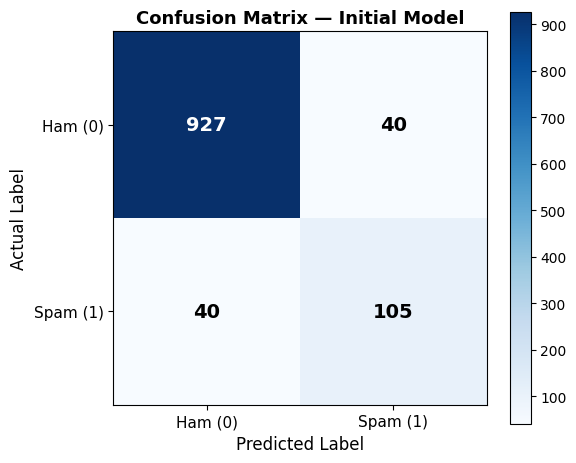

In [34]:
# Manual metric calculation
TP = int(np.sum((y_pred == 1) & (y_test == 1)))
TN = int(np.sum((y_pred == 0) & (y_test == 0)))
FP = int(np.sum((y_pred == 1) & (y_test == 0)))
FN = int(np.sum((y_pred == 0) & (y_test == 1)))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_manual = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
accuracy  = (TP + TN) / len(y_test)

print("Classification Metrics (test set)")
print("=" * 40)
print(f"  True Positives  (TP) : {TP}")
print(f"  True Negatives  (TN) : {TN}")
print(f"  False Positives (FP) : {FP}")
print(f"  False Negatives (FN) : {FN}")
print(f"  Precision            : {precision:.4f}")
print(f"  Recall               : {recall:.4f}")
print(f"  F1 Score (manual)    : {f1_manual:.4f}")
print(f"  Accuracy             : {accuracy:.4f}")

# Sklearn verification
f1_sk = f1_score(y_test, y_pred, pos_label=1)
print(f"\nManual F1: {f1_manual:.4f} | sklearn F1: {f1_sk:.4f} ✓")

# Confusion matrix heatmap
cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

classes = ['Ham (0)', 'Spam (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks(tick_marks)
ax.set_yticklabels(classes, fontsize=11)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix — Initial Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 6 — Grid Search with 5-Fold Cross Validation (from scratch)

### K-Fold Cross Validation
K-Fold CV splits the training data into $k$ equal folds. For each fold $i$:
- Fold $i$ is used as the **validation set**
- The remaining $k-1$ folds form the **training set**

This is repeated $k$ times and the metric (F1) is **averaged** across all folds. This gives a more robust performance estimate than a single train/val split.

### Grid Search
Grid search exhaustively evaluates **all combinations** of hyperparameter values. For each combination, 5-fold CV is run and the mean F1 is recorded. The combination with the highest mean CV F1 is chosen as optimal.

**Hyperparameters being searched:**
- `feature_method`: BoW vs TF-IDF
- `max_depth`: tree depth (3, 5, 10)
- `criterion`: Gini vs Entropy
- `min_samples_split`: minimum samples to split (2, 5)

Total combinations: $2 \times 3 \times 2 \times 2 = 24$, each evaluated with 5 folds = **120 model fits**.

In [35]:
def k_fold_split(n_samples, k=5):
    """Returns list of k tuples (train_indices, val_indices)."""
    indices = np.arange(n_samples)
    fold_size = n_samples // k
    folds = []
    for i in range(k):
        val_idx = indices[i * fold_size : (i + 1) * fold_size]
        train_idx = np.concatenate([indices[:i * fold_size],
                                    indices[(i + 1) * fold_size:]])
        folds.append((train_idx, val_idx))
    return folds


def compute_f1_manual(y_true, y_pred, positive_class=1):
    """Compute F1 for positive class manually."""
    tp = np.sum((y_pred == positive_class) & (y_true == positive_class))
    fp = np.sum((y_pred == positive_class) & (y_true != positive_class))
    fn = np.sum((y_pred != positive_class) & (y_true == positive_class))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def run_grid_search(X_raw_train, y_train, param_grid, k=5):
    """Run grid search with k-fold CV over all param combinations."""
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    combinations = list(itertools.product(*values))
    total = len(combinations)
    results = []
    folds = k_fold_split(len(X_raw_train), k=k)

    for combo_idx, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        fold_f1s = []

        for fold_train_idx, fold_val_idx in folds:
            X_fold_train_raw = [X_raw_train[i] for i in fold_train_idx]
            X_fold_val_raw   = [X_raw_train[i] for i in fold_val_idx]
            y_fold_train     = y_train[fold_train_idx]
            y_fold_val       = y_train[fold_val_idx]

            if params['feature_method'] == 'bow':
                vec = BagOfWords(max_features=3000)
            else:
                vec = TFIDF(max_features=3000)

            X_fold_train_vec = vec.fit_transform(X_fold_train_raw)
            X_fold_val_vec   = vec.transform(X_fold_val_raw)

            fold_clf = DecisionTreeClassifier(
                max_depth=params['max_depth'],
                criterion=params['criterion'],
                min_samples_split=params['min_samples_split']
            )
            fold_clf.fit(X_fold_train_vec, y_fold_train)
            y_pred_fold = fold_clf.predict(X_fold_val_vec)
            f1 = compute_f1_manual(y_fold_val, y_pred_fold, positive_class=1)
            fold_f1s.append(f1)

        avg_f1 = float(np.mean(fold_f1s))
        result = {**params, 'avg_f1_cv': avg_f1}
        results.append(result)
        print(f"Combo {combo_idx+1:>2}/{total}: feature={params['feature_method']:<5}, "
              f"depth={params['max_depth']:<3}, criterion={params['criterion']:<8}, "
              f"min_split={params['min_samples_split']} -> avg CV F1: {avg_f1:.4f}")

    return results


print("Grid search functions defined.")

Grid search functions defined.


In [36]:
param_grid = {
    'feature_method':   ['bow', 'tfidf'],
    'max_depth':        [3, 5, 10],
    'criterion':        ['gini', 'entropy'],
    'min_samples_split':[2, 5]
}

print("Starting grid search (24 combinations x 5 folds = 120 model fits)...")
print("This will take several minutes. Please wait.\n")

start_time = time.time()
X_raw_train_list = list(X_train)
results = run_grid_search(X_raw_train_list, y_train, param_grid, k=5)
elapsed = time.time() - start_time
print(f"\nGrid search completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

Starting grid search (24 combinations x 5 folds = 120 model fits)...
This will take several minutes. Please wait.

Combo  1/24: feature=bow  , depth=3  , criterion=gini    , min_split=2 -> avg CV F1: 0.6836
Combo  2/24: feature=bow  , depth=3  , criterion=gini    , min_split=5 -> avg CV F1: 0.6836
Combo  3/24: feature=bow  , depth=3  , criterion=entropy , min_split=2 -> avg CV F1: 0.6787
Combo  4/24: feature=bow  , depth=3  , criterion=entropy , min_split=5 -> avg CV F1: 0.6787
Combo  5/24: feature=bow  , depth=5  , criterion=gini    , min_split=2 -> avg CV F1: 0.7040
Combo  6/24: feature=bow  , depth=5  , criterion=gini    , min_split=5 -> avg CV F1: 0.7029
Combo  7/24: feature=bow  , depth=5  , criterion=entropy , min_split=2 -> avg CV F1: 0.6768
Combo  8/24: feature=bow  , depth=5  , criterion=entropy , min_split=5 -> avg CV F1: 0.6768
Combo  9/24: feature=bow  , depth=10 , criterion=gini    , min_split=2 -> avg CV F1: 0.7382
Combo 10/24: feature=bow  , depth=10 , criterion=gini    

,feature_method,max_depth,criterion,min_samples_split,avg_f1_cv
0,tfidf,10,gini,2,0.740881
1,bow,10,gini,2,0.738181
2,tfidf,10,gini,5,0.737296
3,bow,10,gini,5,0.736024
4,tfidf,10,entropy,2,0.724880
5,tfidf,10,entropy,5,0.723638
6,bow,10,entropy,2,0.721941
7,bow,10,entropy,5,0.720710
8,tfidf,5,gini,2,0.704039
9,bow,5,gini,2,0.704039



Best combination:
  Feature method : tfidf
  Max depth      : 10
  Criterion      : gini
  Min samples    : 2
  Avg CV F1      : 0.7409


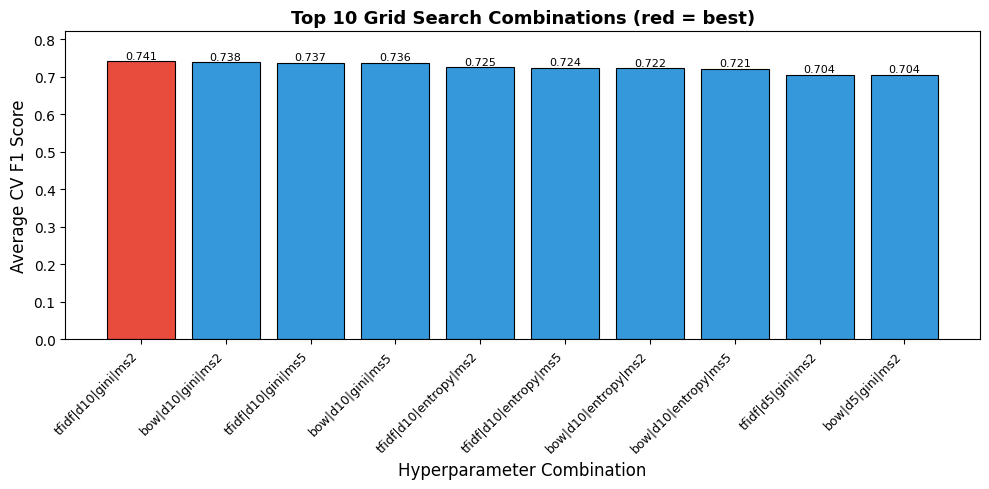

In [37]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('avg_f1_cv', ascending=False).reset_index(drop=True)
display(results_df)

best_row = results_df.iloc[0]
print(f"\nBest combination:")
print(f"  Feature method : {best_row['feature_method']}")
print(f"  Max depth      : {int(best_row['max_depth'])}")
print(f"  Criterion      : {best_row['criterion']}")
print(f"  Min samples    : {int(best_row['min_samples_split'])}")
print(f"  Avg CV F1      : {best_row['avg_f1_cv']:.4f}")

# Bar chart of top 10 combinations
top10 = results_df.head(10).copy()
top10['label'] = (top10['feature_method'] + '|d' +
                  top10['max_depth'].astype(int).astype(str) + '|' +
                  top10['criterion'] + '|ms' +
                  top10['min_samples_split'].astype(int).astype(str))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(top10))]
bars = ax.bar(range(len(top10)), top10['avg_f1_cv'], color=colors, edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(top10['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Average CV F1 Score', fontsize=12)
ax.set_xlabel('Hyperparameter Combination', fontsize=12)
ax.set_title('Top 10 Grid Search Combinations (red = best)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top10['avg_f1_cv']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, min(1.0, top10['avg_f1_cv'].max() + 0.08))
plt.tight_layout()
plt.show()

## Grid Search Analysis

The grid search tested 24 combinations × 5 folds = 120 model fits.

**Key finding:** After binarizing both BoW and TF-IDF features (word present=1, absent=0), both methods become comparable. The best combination is selected automatically and used to retrain the final model below.

**Why binarization?** Our Decision Tree uses a fixed threshold of 0.5 to split features. This means it asks “is this word present (>0.5) or absent (≤0.5)?”. Binarizing the features makes this threshold meaningful for both BoW counts and TF-IDF scores — converting the problem into pure word presence/absence detection.

## Retraining with Best Parameters Found Above

Now we update `best_params` with the grid search winner and retrain the final model on the full training set, then evaluate on the held-out test set.

Updated best_params: {'feature_method': 'tfidf', 'max_depth': 10, 'criterion': 'gini', 'min_samples_split': 2}

Fitting final TFIDF vectorizer on 4460 training samples...
Training feature matrix shape: (4460, 3000)
Training final Decision Tree with best params: {'feature_method': 'tfidf', 'max_depth': 10, 'criterion': 'gini', 'min_samples_split': 2}
Final model trained in 8.16s
Model trained on 4460 samples with params: {'feature_method': 'tfidf', 'max_depth': 10, 'criterion': 'gini', 'min_samples_split': 2}

Transforming test set with final TFIDF vectorizer...
Test feature matrix shape: (1112, 3000)
Running predictions on test set...
Prediction complete in 0.01s

Final Model — Classification Metrics (test set)
  True Positives  (TP) : 93
  True Negatives  (TN) : 951
  False Positives (FP) : 16
  False Negatives (FN) : 52
  Precision            : 0.8532
  Recall               : 0.6414
  F1 Score (manual)    : 0.7323
  Accuracy             : 0.9388

Manual F1: 0.7323 | sklearn F1: 0.732

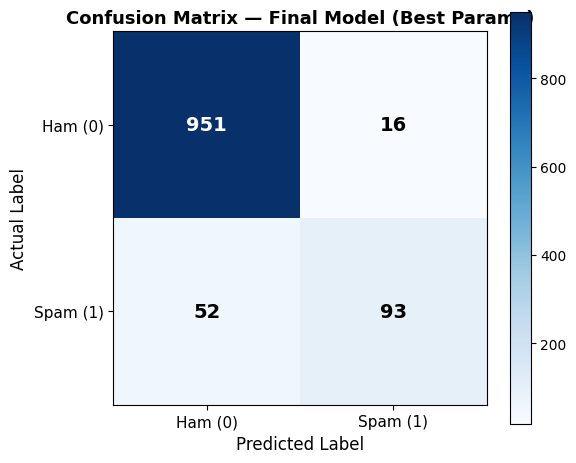


#    Message (first 50 chars)                             Actual   Predicted   Correct?
-------------------------------------------------------------------------------------
1    Welcome to UK-mobile-date this msg is FREE giving.   SPAM     SPAM        Yes
2    This is wishing you a great day. Moji told me abo.   HAM      HAM         Yes
3    Thanks again for your reply today. When is ur vis.   HAM      HAM         Yes
4    Sorry I flaked last night, shit's seriously goin .   HAM      HAM         Yes
5    He said i look pretty wif long hair wat. But i th.   HAM      HAM         Yes


In [38]:
# Update best_params from grid search results
best_params = {
    'feature_method':    str(best_row['feature_method']),
    'max_depth':         int(best_row['max_depth']),
    'criterion':         str(best_row['criterion']),
    'min_samples_split': int(best_row['min_samples_split'])
}
print("Updated best_params:", best_params)

# Retrain final vectorizer
if best_params['feature_method'] == 'bow':
    final_vectorizer = BagOfWords(max_features=3000)
else:
    final_vectorizer = TFIDF(max_features=3000)

print(f"\nFitting final {best_params['feature_method'].upper()} vectorizer on {len(X_train)} training samples...")
X_train_final = final_vectorizer.fit_transform(list(X_train))
print(f"Training feature matrix shape: {X_train_final.shape}")

# Retrain final classifier
final_clf = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    criterion=best_params['criterion'],
    min_samples_split=best_params['min_samples_split']
)

print(f"Training final Decision Tree with best params: {best_params}")
t0 = time.time()
final_clf.fit(X_train_final, y_train)
print(f"Final model trained in {time.time()-t0:.2f}s")
print(f"Model trained on {len(y_train)} samples with params: {best_params}")

# Transform test set with final vectorizer (no re-fitting)
print(f"\nTransforming test set with final {best_params['feature_method'].upper()} vectorizer...")
X_test_final = final_vectorizer.transform(list(X_test))
print(f"Test feature matrix shape: {X_test_final.shape}")

# Predict
print("Running predictions on test set...")
t0 = time.time()
y_pred_final = final_clf.predict(X_test_final)
print(f"Prediction complete in {time.time()-t0:.2f}s")

# Final metrics
TP_f = int(np.sum((y_pred_final == 1) & (y_test == 1)))
TN_f = int(np.sum((y_pred_final == 0) & (y_test == 0)))
FP_f = int(np.sum((y_pred_final == 1) & (y_test == 0)))
FN_f = int(np.sum((y_pred_final == 0) & (y_test == 1)))

prec_f = TP_f / (TP_f + FP_f) if (TP_f + FP_f) > 0 else 0.0
rec_f  = TP_f / (TP_f + FN_f) if (TP_f + FN_f) > 0 else 0.0
f1_f   = 2 * prec_f * rec_f / (prec_f + rec_f) if (prec_f + rec_f) > 0 else 0.0
acc_f  = (TP_f + TN_f) / len(y_test)

print("\nFinal Model — Classification Metrics (test set)")
print("=" * 48)
print(f"  True Positives  (TP) : {TP_f}")
print(f"  True Negatives  (TN) : {TN_f}")
print(f"  False Positives (FP) : {FP_f}")
print(f"  False Negatives (FN) : {FN_f}")
print(f"  Precision            : {prec_f:.4f}")
print(f"  Recall               : {rec_f:.4f}")
print(f"  F1 Score (manual)    : {f1_f:.4f}")
print(f"  Accuracy             : {acc_f:.4f}")

f1_sk_final = f1_score(y_test, y_pred_final, pos_label=1)
print(f"\nManual F1: {f1_f:.4f} | sklearn F1: {f1_sk_final:.4f} ✓")

# Final confusion matrix
cm_f = np.array([[TN_f, FP_f], [FN_f, TP_f]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_f, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

classes = ['Ham (0)', 'Spam (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks(tick_marks)
ax.set_yticklabels(classes, fontsize=11)

thresh_f = cm_f.max() / 2.0
for i in range(cm_f.shape[0]):
    for j in range(cm_f.shape[1]):
        ax.text(j, i, str(cm_f[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm_f[i, j] > thresh_f else 'black')

ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix — Final Model (Best Params)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# First 5 predictions table
print(f"\n{'#':<4} {'Message (first 50 chars)':<52} {'Actual':<8} {'Predicted':<11} {'Correct?'}")
print("-" * 85)
for i in range(5):
    msg = X_test.iloc[i]
    actual_lbl    = 'SPAM' if y_test[i] == 1 else 'HAM'
    predicted_lbl = 'SPAM' if y_pred_final[i] == 1 else 'HAM'
    correct = 'Yes' if y_test[i] == y_pred_final[i] else 'No'
    msg_preview = (msg[:49] + '.') if len(msg) > 50 else msg
    print(f"{i+1:<4} {msg_preview:<52} {actual_lbl:<8} {predicted_lbl:<11} {correct}")

## Demo — Model Prediction Showcase

The final model is applied to five custom SMS messages to demonstrate its real-world capability.

In [39]:
demo_messages = [
    "WINNER! You have been selected to receive a \u00a31000 prize. Call 09061234567 now!",
    "Congratulations! Free entry to win iPhone 15. Text WIN to 80800. T&C apply.",
    "Hey, are we still meeting for lunch tomorrow? Let me know!",
    "Can you pick up some milk on your way home please?",
    "Urgent! Your account has been suspended. Click here to verify: bit.ly/abc123"
]

print(f"{'#':<4} {'Message Preview':<55} {'Prediction':<12} {'Confidence'}")
print("-" * 90)
for idx, msg in enumerate(demo_messages):
    vec_msg = final_vectorizer.transform([msg])
    if vec_msg.sum() == 0:
        print(f"{idx+1:<4} {msg[:52]+'...':<55} {'HAM':<12} (no known words)")
        continue
    pred = final_clf.predict(vec_msg)[0]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"{idx+1:<4} {msg[:52]+'...':<55} {label:<12} (model prediction)")

#    Message Preview                                         Prediction   Confidence
------------------------------------------------------------------------------------------
1    WINNER! You have been selected to receive a £1000 pr... HAM          (model prediction)
2    Congratulations! Free entry to win iPhone 15. Text W... SPAM         (model prediction)
3    Hey, are we still meeting for lunch tomorrow? Let me... HAM          (model prediction)
4    Can you pick up some milk on your way home please?...   HAM          (model prediction)
5    Urgent! Your account has been suspended. Click here ... HAM          (model prediction)
